## Setup & Imports


In [ ]:
import sqlite3, json, warnings, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# Categorical biomarkers used as model features. Each value is one of:
# NEGATIVE, POSITIVE, NO_DATA. The four markers urobilinogen / ketone /
# bilirubin / ascorbic_acid are intentionally excluded — they are NO_DATA in
# the vast majority of measurements (including newer datasets) so they carry
# no usable signal. They remain in the DB but are not fed to the model.
BIOMARKER_CATS = [
    'leukocytes', 'nitrite', 'protein', 'blood', 'glucose',
]

# Per-biomarker positive-streak features: count of consecutive POSITIVE results
# for that biomarker ending at this measurement, computed per patient in
# chronological order. Lets the model distinguish "first positive ever" from
# "second positive in a row".
STREAK_FEATURES = [f'{b}_streak' for b in BIOMARKER_CATS]

# Numeric measurement features.
NUMERIC_FEATURES = ['ph']

# Derived counters and per-patient aggregates.
DERIVED_FEATURES = ['n_positive', 'n_no_data', 'max_pos_streak', 'n_prior_measurements']

# Patient demographics; the CSV stores them as ranges ("20-29"), so we use the midpoint.
DEMO_FEATURES = ['age_mid', 'height_mid', 'weight_mid']

# Final feature vector fed to the model.
FEATURES = BIOMARKER_CATS + STREAK_FEATURES + NUMERIC_FEATURES + DERIVED_FEATURES + DEMO_FEATURES

FEATURE_UNITS = {
    **{c: '' for c in BIOMARKER_CATS},
    **{f'{b}_streak': '×' for b in BIOMARKER_CATS},
    'ph': 'pH',
    'n_positive': '', 'n_no_data': '',
    'max_pos_streak': '×', 'n_prior_measurements': '',
    'age_mid': 'y', 'height_mid': 'cm', 'weight_mid': 'kg',
}

FEATURE_REFS = {
    **{c: 1 for c in BIOMARKER_CATS},
    **{f'{b}_streak': 5 for b in BIOMARKER_CATS},
    'ph': 14,
    'n_positive': len(BIOMARKER_CATS), 'n_no_data': len(BIOMARKER_CATS),
    'max_pos_streak': 5, 'n_prior_measurements': 10,
    'age_mid': 90, 'height_mid': 200, 'weight_mid': 120,
}

UNCERTAINTY_THRESHOLD = 0.75

print('Setup completed')


## Load source data

The notebook expects three pseudonymised CSVs from module `1_pseudonymization`:

- `biomarkers_pseudo.csv` — one row per urinalysis measurement
- `patients_pseudo.csv` — demographic ranges per patient
- `measurements_pseudo.csv` — provides `created_date` per measurement (needed so the per-patient streak features can be computed chronologically)

They are loaded into a small SQLite database under `data/db/` so the active-learning workflow (labels, sources, confidences) can be persisted between sessions, the same way module `2_uroflow_labeling` does it.


In [ ]:
DB_DIR  = 'data/db/'
DB_NAME = 'biomarkers.db'
DB_PATH = DB_DIR + DB_NAME

# Default source paths — adjust if the CSVs live elsewhere.
SRC_BIOMARKERS   = '../1_pseudonymization/data/out/biomarkers_pseudo.csv'
SRC_PATIENTS     = '../1_pseudonymization/data/out/patients_pseudo.csv'
SRC_MEASUREMENTS = '../1_pseudonymization/data/out/measurements_pseudo.csv'

os.makedirs(DB_DIR, exist_ok=True)
os.makedirs('data/out', exist_ok=True)


def _load_biomarkers_with_dates(src_biomarkers, src_measurements):
    """Join biomarker rows with their created_date from measurements_pseudo.csv."""
    df_b = pd.read_csv(src_biomarkers)
    df_m = pd.read_csv(src_measurements, usecols=['measurement_id', 'created_date'])
    df = df_b.merge(df_m, on='measurement_id', how='left')
    n_missing = df['created_date'].isna().sum()
    if n_missing:
        print(f'  Warning: {n_missing} biomarker rows have no matching created_date — '
              f'their streaks will be ordered after all dated rows.')
    return df


def _build_db(db_path, src_biomarkers, src_patients, src_measurements):
    """Create the SQLite database from the source CSVs."""
    df_b = _load_biomarkers_with_dates(src_biomarkers, src_measurements)
    df_p = pd.read_csv(src_patients)

    conn = sqlite3.connect(db_path)
    conn.row_factory = sqlite3.Row
    conn.execute('''
        CREATE TABLE measurements (
            id              INTEGER PRIMARY KEY AUTOINCREMENT,
            measurement_id  TEXT UNIQUE,
            patient_id      TEXT,
            created_date    TEXT,
            leukocytes      TEXT, nitrite       TEXT, protein     TEXT,
            blood           TEXT, glucose       TEXT, ascorbic_acid TEXT,
            bilirubin       TEXT, ketone        TEXT, urobilinogen TEXT,
            ph              REAL,
            avg_flow        REAL,
            label           TEXT DEFAULT NULL,
            label_source    TEXT DEFAULT NULL,
            confidence      REAL DEFAULT NULL,
            reviewed_at     TEXT DEFAULT NULL
        )''')
    conn.execute('''
        CREATE TABLE patients (
            patient_id    TEXT PRIMARY KEY,
            age_range     TEXT,
            height_range  TEXT,
            weight_range  TEXT
        )''')

    df_b.to_sql('measurements', conn, if_exists='append', index=False)
    df_p.to_sql('patients', conn, if_exists='append', index=False)
    conn.commit()
    return conn


def _migrate_db(conn, src_biomarkers, src_measurements):
    """Add created_date column if missing and backfill from measurements_pseudo.csv."""
    cols = {r[1] for r in conn.execute("PRAGMA table_info(measurements)")}
    if 'created_date' in cols:
        return
    print('  Migrating: adding created_date column and backfilling from measurements_pseudo.csv')
    conn.execute('ALTER TABLE measurements ADD COLUMN created_date TEXT')
    df = _load_biomarkers_with_dates(src_biomarkers, src_measurements)
    for _, r in df[['measurement_id', 'created_date']].iterrows():
        if pd.notna(r['created_date']):
            conn.execute(
                'UPDATE measurements SET created_date=? WHERE measurement_id=?',
                (r['created_date'], r['measurement_id'])
            )
    conn.commit()


if not os.path.exists(DB_PATH):
    missing = [p for p in (SRC_BIOMARKERS, SRC_PATIENTS, SRC_MEASUREMENTS)
               if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError(
            'Source CSV(s) not found:\n  ' + '\n  '.join(missing) +
            '\nAdjust SRC_BIOMARKERS / SRC_PATIENTS / SRC_MEASUREMENTS.'
        )
    print(f'Creating fresh database from CSVs → {DB_PATH}')
    conn = _build_db(DB_PATH, SRC_BIOMARKERS, SRC_PATIENTS, SRC_MEASUREMENTS)
else:
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    _migrate_db(conn, SRC_BIOMARKERS, SRC_MEASUREMENTS)
    print(f'Database connected: {DB_PATH}')

n_meas = conn.execute('SELECT COUNT(*) FROM measurements').fetchone()[0]
n_pat  = conn.execute('SELECT COUNT(*) FROM patients').fetchone()[0]
n_lbl  = conn.execute('SELECT COUNT(*) FROM measurements WHERE label IS NOT NULL').fetchone()[0]
print(f'  {n_meas} measurements | {n_pat} patients | {n_lbl} labeled | {n_meas - n_lbl} unlabeled')


## Feature engineering

The biomarker columns are categorical (`NEGATIVE` / `POSITIVE` / `NO_DATA`). For the model we map them to:

- `POSITIVE` → `1`
- `NEGATIVE` → `0`
- `NO_DATA`  → `NaN` (XGBoost handles missing values natively)

On top of that, per-patient sequential context is computed in chronological order of `created_date`:

- `<biomarker>_streak` — number of consecutive POSITIVE results for that biomarker ending at this measurement. `0` if the current measurement is not POSITIVE, `1` for the first POSITIVE, `2` for the second in a row, etc. `NEGATIVE` and `NO_DATA` both break the streak.
- `max_pos_streak` — maximum streak across the five biomarker streaks at this row
- `n_prior_measurements` — count of earlier measurements for the same patient

Plus the simpler counters `n_positive` and `n_no_data` over the five model biomarkers, and the demographic midpoints.


In [ ]:
POS, NEG, NA = 'POSITIVE', 'NEGATIVE', 'NO_DATA'


def encode_biomarker(v):
    if v == POS: return 1.0
    if v == NEG: return 0.0
    return np.nan  # NO_DATA or anything unexpected


def range_midpoint(s):
    """'20-29' → 24.5; returns NaN on unparseable input."""
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return np.nan
    m = re.match(r'^\s*(-?\d+)\s*-\s*(-?\d+)\s*$', str(s))
    if not m:
        return np.nan
    lo, hi = int(m.group(1)), int(m.group(2))
    return (lo + hi) / 2.0


def _streak_for_series(values_is_pos):
    """Positive-streak counts for a chronological sequence (1=positive, 0=other)."""
    out = np.zeros(len(values_is_pos), dtype=int)
    cur = 0
    for i, v in enumerate(values_is_pos):
        cur = cur + 1 if v else 0
        out[i] = cur
    return out


def _add_sequential_features(df):
    """Add per-patient streak features in chronological order of created_date.

    Returns a frame with the same index as the input but enriched with
    `<biomarker>_streak`, `max_pos_streak` and `n_prior_measurements`.
    """
    orig_idx = df.index
    df = df.sort_values(['patient_id', 'created_date'], kind='stable',
                        na_position='last').copy()

    df['n_prior_measurements'] = df.groupby('patient_id').cumcount()

    for b in BIOMARKER_CATS:
        is_pos = (df[b] == POS).astype(int).to_numpy()
        streaks = np.zeros(len(df), dtype=int)
        # groupby(..., sort=False).indices preserves the sorted order within each group
        for _pid, idxs in df.groupby('patient_id', sort=False).indices.items():
            streaks[idxs] = _streak_for_series(is_pos[idxs])
        df[f'{b}_streak'] = streaks

    df['max_pos_streak'] = df[STREAK_FEATURES].max(axis=1)
    return df.reindex(orig_idx)


def build_feature_frame(conn):
    """Return a DataFrame with the model's feature columns + id/label columns."""
    df_m = pd.read_sql('SELECT * FROM measurements', conn)
    df_p = pd.read_sql('SELECT * FROM patients', conn)

    # Encode categorical biomarkers (only the five used as model features)
    for c in BIOMARKER_CATS:
        df_m[c + '_enc'] = df_m[c].map(encode_biomarker)

    # Sequential per-patient streak features (needs raw biomarker strings + created_date)
    df_m = _add_sequential_features(df_m)

    # Simple counters over the model biomarker set
    raw = df_m[BIOMARKER_CATS]
    df_m['n_positive'] = (raw == POS).sum(axis=1)
    df_m['n_no_data']  = (raw == NA).sum(axis=1)

    # Merge demographics
    df_p['age_mid']    = df_p['age_range'].map(range_midpoint)
    df_p['height_mid'] = df_p['height_range'].map(range_midpoint)
    df_p['weight_mid'] = df_p['weight_range'].map(range_midpoint)
    df = df_m.merge(df_p[['patient_id'] + DEMO_FEATURES], on='patient_id', how='left')

    # Use encoded biomarker columns under the original feature names for the model
    for c in BIOMARKER_CATS:
        df[c] = df[c + '_enc']
    return df


df_feat = build_feature_frame(conn)
print(f'Feature frame shape: {df_feat.shape}')
print('\nFeature summary:')
print(df_feat[FEATURES].describe().round(2).T[['count', 'mean', 'std', 'min', 'max']])
print('\nStreak distribution (max_pos_streak):')
print(df_feat['max_pos_streak'].value_counts().sort_index())


## Data exploration


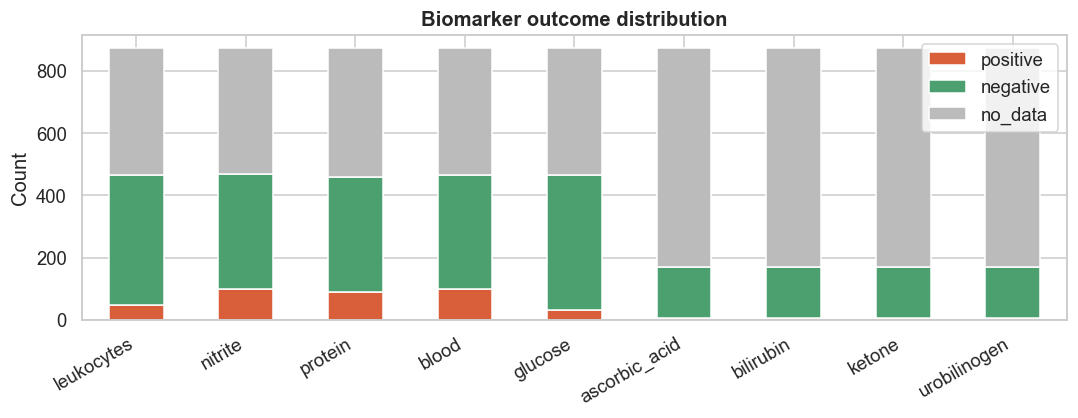

In [4]:
# Biomarker positivity rates
fig, ax = plt.subplots(figsize=(10, 4))
rates = pd.DataFrame({
    'positive': [(df_feat[c] == 1).sum() for c in BIOMARKER_CATS],
    'negative': [(df_feat[c] == 0).sum() for c in BIOMARKER_CATS],
    'no_data':  [df_feat[c].isna().sum() for c in BIOMARKER_CATS],
}, index=BIOMARKER_CATS)
rates.plot(kind='bar', stacked=True, ax=ax,
           color=['#D95F3B', '#4C9F6F', '#bbb'], edgecolor='white')
ax.set_title('Biomarker outcome distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.legend(loc='upper right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


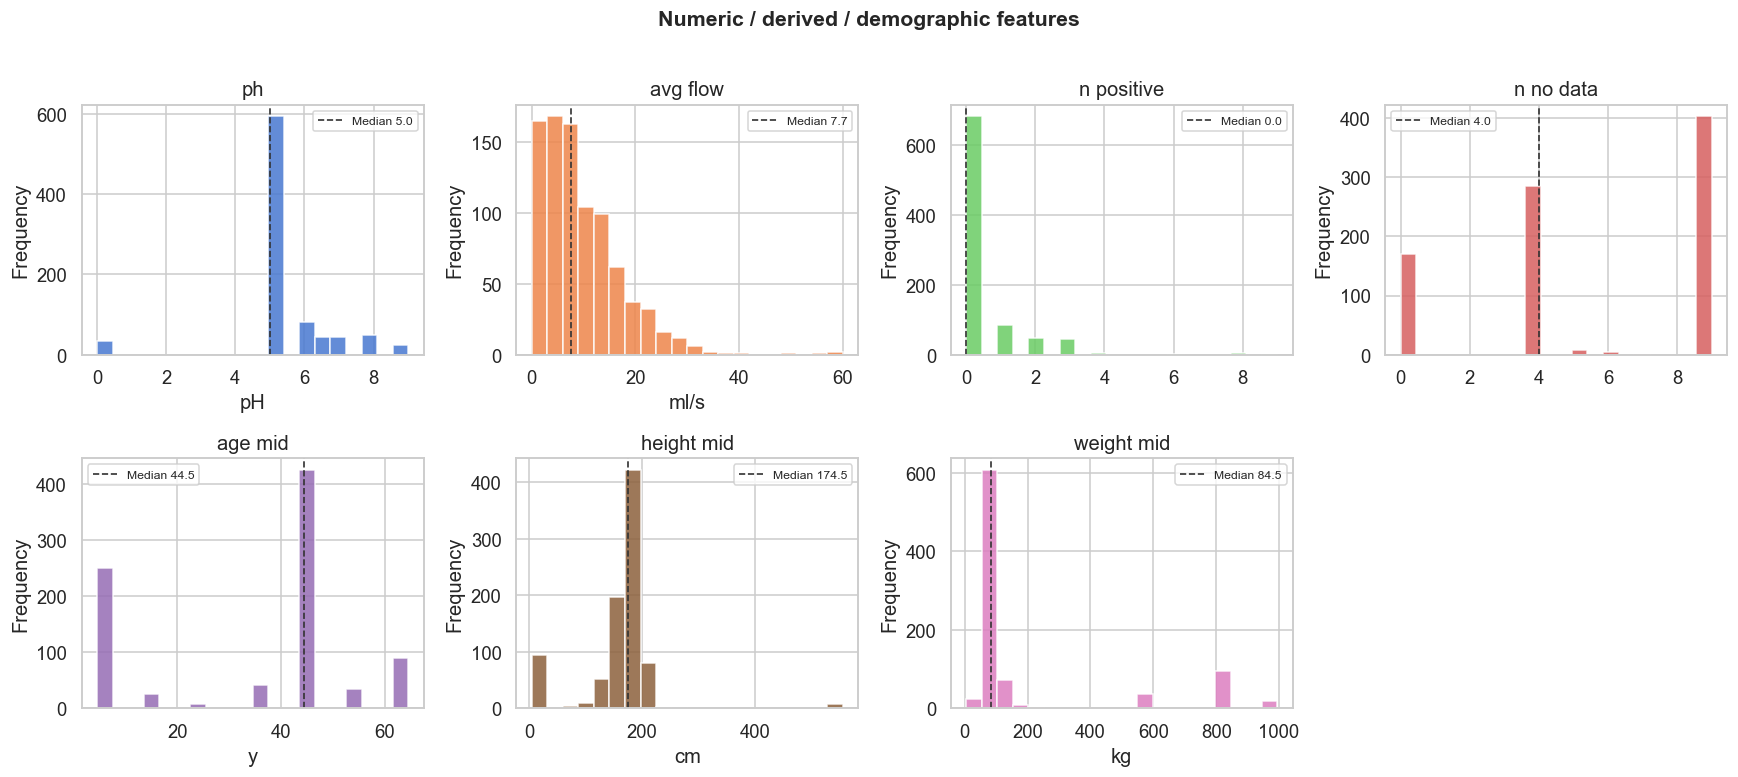

In [5]:
# Numeric & derived feature histograms
num_cols = NUMERIC_FEATURES + DERIVED_FEATURES + DEMO_FEATURES
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
colors = sns.color_palette('muted', len(num_cols))
for ax, feat, col in zip(axes.flat, num_cols, colors):
    data = df_feat[feat].dropna()
    if data.empty:
        ax.set_title(f'{feat} (no data)'); ax.axis('off'); continue
    ax.hist(data, bins=20, color=col, alpha=0.85, edgecolor='white')
    ax.set_title(feat.replace('_', ' '))
    ax.set_xlabel(FEATURE_UNITS[feat])
    ax.set_ylabel('Frequency')
    ax.axvline(data.median(), color='#333', ls='--', lw=1.1,
               label=f'Median {data.median():.1f}')
    ax.legend(fontsize=8)
# Hide any unused subplot
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.suptitle('Numeric / derived / demographic features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


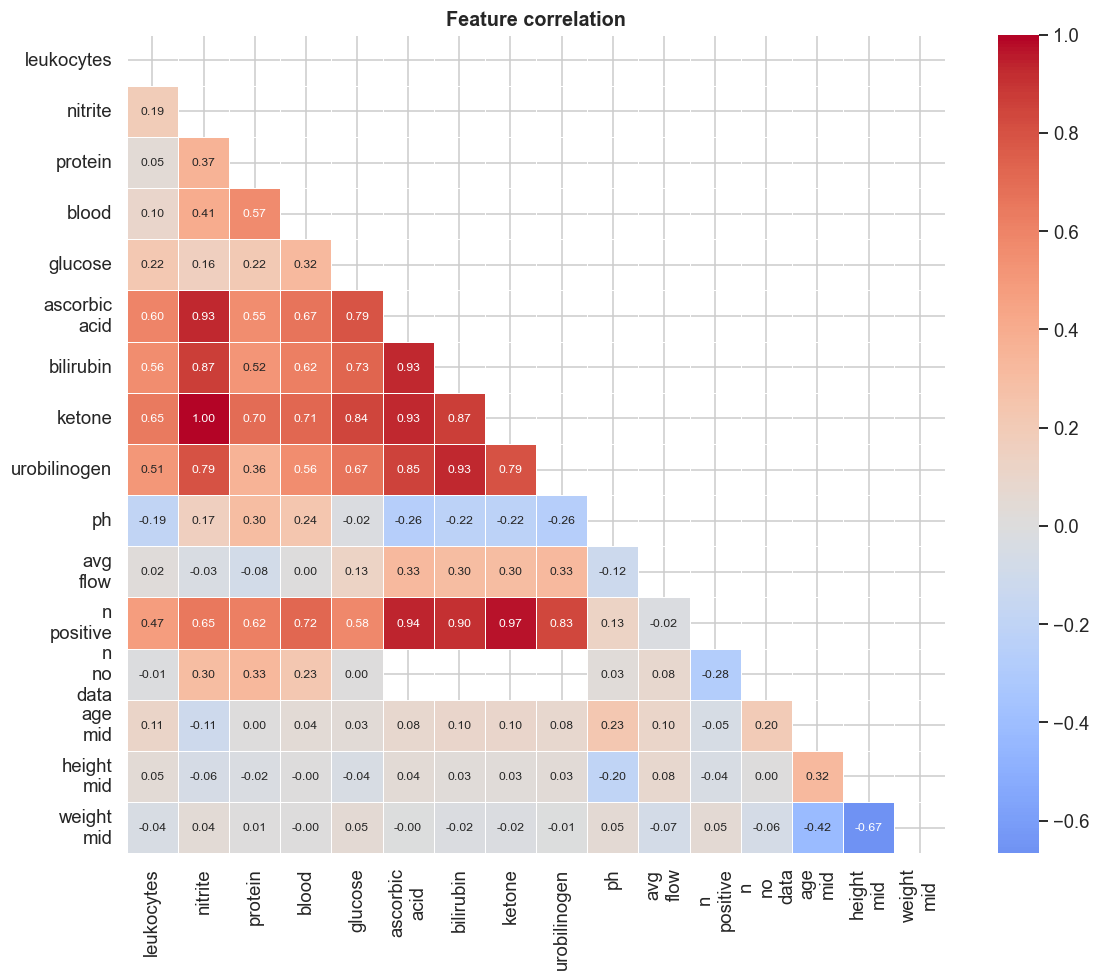

In [6]:
# Correlation matrix across the full feature set
fig, ax = plt.subplots(figsize=(11, 9))
corr = df_feat[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=.4, annot_kws={'size': 8},
            xticklabels=[f.replace('_', '\n') for f in FEATURES],
            yticklabels=[f.replace('_', '\n') for f in FEATURES])
ax.set_title('Feature correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Active Learning Engine


In [ ]:
def _notnan(v):
    return v is not None and not (isinstance(v, float) and np.isnan(v))


# Clinical safety rules — deterministic overrides for medically unambiguous
# biomarker patterns. They never train the model; they only override predictions
# at inference time so the learning signal stays intact. Keep this list small.
CLINICAL_RULES = [
    # Many positives across the biomarker panel — strongest signal, fires first.
    dict(name='many_positives',
         check=lambda r: _notnan(r.get('n_positive')) and r['n_positive'] >= 4,
         label='critical', confidence=1.0),
    # Repeated positives for the *same* biomarker (≥2 consecutive) → warning.
    # Captures the "first time is okay, second time in a row is concerning" intuition.
    dict(name='positive_streak',
         check=lambda r: _notnan(r.get('max_pos_streak')) and r['max_pos_streak'] >= 2,
         label='warning', confidence=0.9),
    # Extreme pH outside the physiological range.
    dict(name='extreme_ph',
         check=lambda r: _notnan(r.get('ph')) and (r['ph'] < 4.0 or r['ph'] > 8.5),
         label='warning', confidence=0.9),
]


def _apply_clinical_rule(row_dict):
    for rule in CLINICAL_RULES:
        try:
            if rule['check'](row_dict):
                return rule['label'], rule['confidence'], rule['name']
        except Exception:
            continue
    return None, None, None


def _feature_frame_indexed(conn):
    """Helper: feature frame indexed by measurements.id (the autoincrement PK)."""
    df = build_feature_frame(conn)
    return df.set_index('id')


class BiomarkerActiveLearner:
    """Active-learning loop for urinalysis biomarker data."""

    def __init__(self, conn, threshold=UNCERTAINTY_THRESHOLD):
        self.conn = conn
        self.threshold = threshold
        self.model = XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            random_state=42, n_jobs=-1,
            eval_metric='mlogloss', tree_method='hist',
        )
        self.le = LabelEncoder()
        self.trained = False
        self.history = []  # [(iteration, n_labeled, cv_accuracy)]

    # ── Data
    def _split_labeled(self):
        df = _feature_frame_indexed(self.conn)
        mask = df['label'].notna()
        return df[mask], df[~mask]

    def load_labeled(self):
        lbl, _ = self._split_labeled()
        if lbl.empty:
            return None, None, []
        return lbl[FEATURES].to_numpy(dtype=float), lbl['label'].tolist(), lbl.index.tolist()

    def load_unlabeled(self):
        _, unl = self._split_labeled()
        if unl.empty:
            return [], None
        return unl.index.tolist(), unl[FEATURES].to_numpy(dtype=float)

    # ── Training
    def train(self, verbose=True):
        X, y, _ = self.load_labeled()
        if X is None or len(set(y)) < 2:
            if verbose:
                print(f'Not enough labels ({len(y) if y else 0}) or only one class.')
            return False
        y_enc = self.le.fit_transform(y)
        sw = compute_sample_weight('balanced', y_enc)
        self.model.fit(X, y_enc, sample_weight=sw)
        self.trained = True
        if verbose:
            cv = cross_val_score(self.model, X, y_enc,
                                 cv=min(5, len(set(y_enc))), scoring='accuracy')
            acc = cv.mean()
            self.history.append((len(self.history) + 1, len(y), acc))
            print(f'Training: {len(y)} labels | Classes: {list(self.le.classes_)} | CV-Acc: {acc:.1%}')
        return True

    # ── Uncertainty
    def _entropy(self, proba):
        ent = -np.sum(proba * np.log2(proba + 1e-10), axis=1)
        return ent / np.log2(max(len(self.le.classes_), 2))

    def get_uncertain_cases(self, n=10):
        if not self.trained:
            return pd.DataFrame()
        ids, X = self.load_unlabeled()
        if not ids:
            return pd.DataFrame()
        proba = self.model.predict_proba(X)
        pred  = self.le.inverse_transform(proba.argmax(axis=1))
        conf  = proba.max(axis=1)
        unc   = self._entropy(proba)
        df = pd.DataFrame(X, columns=FEATURES)
        df.insert(0, 'id', ids)
        df['predicted'] = pred
        df['confidence'] = conf
        df['uncertainty'] = unc
        rule_mask = df.apply(lambda r: _apply_clinical_rule(r.to_dict())[0] is not None, axis=1)
        df = df[~rule_mask & (df['confidence'] < self.threshold)]
        return df.sort_values('uncertainty', ascending=False).head(n).reset_index(drop=True)

    def auto_label(self):
        if not self.trained:
            return 0
        ids, X = self.load_unlabeled()
        if not ids:
            return 0
        proba = self.model.predict_proba(X)
        pred  = self.le.inverse_transform(proba.argmax(axis=1))
        conf  = proba.max(axis=1)
        adaptive_threshold = max(self.threshold, np.quantile(conf, 0.70))

        model_count = 0
        rule_count  = 0
        for i, (mid, p, c) in enumerate(zip(ids, pred, conf)):
            row_dict = {f: X[i, j] for j, f in enumerate(FEATURES)}
            rule_label, rule_conf, rule_name = _apply_clinical_rule(row_dict)
            if rule_label is not None:
                self.conn.execute("""
                    UPDATE measurements
                    SET label=?, label_source=?, confidence=?, reviewed_at=?
                    WHERE id=?""",
                    (rule_label, f'rule:{rule_name}', float(rule_conf),
                     datetime.now().isoformat(), int(mid)))
                rule_count += 1
            elif c >= adaptive_threshold:
                self.conn.execute("""
                    UPDATE measurements
                    SET label=?, label_source='model', confidence=?, reviewed_at=?
                    WHERE id=?""",
                    (p, float(c), datetime.now().isoformat(), int(mid)))
                model_count += 1
        self.conn.commit()
        if rule_count:
            print(f'  → {rule_count} cases labeled via clinical safety rule')
        return model_count + rule_count

    def apply_label(self, mid, label):
        self.conn.execute("""
            UPDATE measurements
            SET label=?, label_source='human', confidence=1.0, reviewed_at=?
            WHERE id=?""", (label, datetime.now().isoformat(), int(mid)))
        self.conn.commit()

    def reset_labels(self):
        self.conn.execute("""UPDATE measurements
                             SET label=NULL, label_source=NULL,
                                 confidence=NULL, reviewed_at=NULL""")
        self.conn.commit()
        self.trained = False
        self.history = []

    # ── Stats
    def stats(self):
        c = self.conn
        total   = c.execute('SELECT COUNT(*) FROM measurements').fetchone()[0]
        labeled = c.execute("SELECT COUNT(*) FROM measurements WHERE label IS NOT NULL").fetchone()[0]
        human   = c.execute("SELECT COUNT(*) FROM measurements WHERE label_source='human'").fetchone()[0]
        model   = c.execute("SELECT COUNT(*) FROM measurements WHERE label_source='model'").fetchone()[0]
        rule    = c.execute("SELECT COUNT(*) FROM measurements WHERE label_source LIKE 'rule:%'").fetchone()[0]
        return dict(total=total, labeled=labeled, unlabeled=total - labeled,
                    human=human, model_auto=model, rule=rule)


learner = BiomarkerActiveLearner(conn)
s = learner.stats()
print(f'Status: {s["total"]} measurements | {s["labeled"]} labeled | {s["unlabeled"]} unlabeled')


## Seed Labeling


In [ ]:
LABEL_OPTIONS = ['normal', 'warning', 'critical', 'invalid']
SEED_LABEL_TARGET = 50  # random samples drawn for initial human labeling


def _fmt_feat(val, unit):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "<span style='color:#999'>n/a</span>"
    return f"{val:.2f} {unit}".strip()


def _bar_width_pct(val, ref):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return 0
    return min(100, abs(val) / ref * 100)


def _biomarker_panel_html(row, biomarker_cols=BIOMARKER_CATS):
    """Render the categorical biomarker results as a coloured chip grid.

    For POSITIVE markers, the consecutive-positive streak is shown as a
    multiplier (e.g. "POSITIVE × 2") and the chip darkens when streak ≥ 2,
    so the labeler can see at a glance whether this is a first-time or a
    repeating finding.
    """
    cells_html = []
    for c in biomarker_cols:
        v = row[c]
        try:
            streak = int(row.get(f'{c}_streak', 0) or 0)
        except (ValueError, TypeError):
            streak = 0
        if v is None or (isinstance(v, float) and np.isnan(v)):
            color, label = '#bbb', 'no data'
        elif v == 1:
            if streak >= 2:
                color, label = '#A82A1B', f'POSITIVE × {streak}'
            else:
                color, label = '#D95F3B', 'POSITIVE'
        else:
            color, label = '#4C9F6F', 'negative'
        cells_html.append(
            f"<div style='display:inline-block;margin:3px;padding:6px 10px;"
            f"background:{color};color:white;border-radius:6px;font-size:0.85em;"
            f"min-width:120px;text-align:center'>"
            f"<b>{c}</b><br>{label}</div>"
        )
    return '<div>' + ''.join(cells_html) + '</div>'


class SeedLabelingUI:
    def __init__(self, learner, label_options):
        self.learner = learner
        self.labels  = label_options
        self.queue   = []
        self.idx     = 0
        self.out     = widgets.Output()
        self._load_queue()
        self._build_ui()

    def _load_queue(self):
        rows = self.learner.conn.execute(
            f'SELECT id FROM measurements WHERE label IS NULL '
            f'ORDER BY RANDOM() LIMIT {SEED_LABEL_TARGET}'
        ).fetchall()
        self.queue = [r['id'] for r in rows]
        self.idx = 0

    def _current_row(self):
        if self.idx >= len(self.queue):
            return None
        mid = self.queue[self.idx]
        df = _feature_frame_indexed(self.learner.conn)
        if mid not in df.index:
            return None
        return df.loc[mid]

    def _build_ui(self):
        self.lbl_progress = widgets.HTML()
        self.biomarker_html = widgets.HTML()
        self.numeric_html = widgets.HTML()

        btn_style = widgets.Layout(width='140px', height='38px')
        btn_colors = ['#4C9F6F', '#E8A838', '#D95F3B', '#8A8A8A']
        self.label_buttons = []
        for lbl, col in zip(self.labels, btn_colors[:len(self.labels)]):
            b = widgets.Button(description=lbl, layout=btn_style,
                               style={'button_color': col})
            b.on_click(lambda ev, l=lbl: self._on_label(l))
            self.label_buttons.append(b)

        self.custom_input = widgets.Text(placeholder='Eigenes Label...',
                                         layout=widgets.Layout(width='200px'))
        self.custom_btn = widgets.Button(description='Vergeben',
                                         layout=widgets.Layout(width='100px'))
        self.custom_btn.on_click(lambda _: self._on_label(self.custom_input.value.strip()))

        self.skip_btn = widgets.Button(description='⏭ Überspringen',
                                       layout=widgets.Layout(width='160px'))
        self.skip_btn.on_click(lambda _: self._advance())

        self.ui = widgets.VBox([
            self.lbl_progress,
            self.biomarker_html,
            self.numeric_html,
            widgets.HTML('<hr style="margin:8px 0">'),
            widgets.HTML('<b>Label vergeben:</b>'),
            widgets.HBox(self.label_buttons,
                         layout=widgets.Layout(flex_flow='row wrap', gap='6px')),
            widgets.HTML('<b>Oder eigenes Label:</b>'),
            widgets.HBox([self.custom_input, self.custom_btn]),
            widgets.HBox([self.skip_btn]),
            self.out,
        ], layout=widgets.Layout(padding='16px', border='1px solid #ddd',
                                  border_radius='8px', max_width='820px'))
        self._render()
        display(self.ui)

    def _render(self):
        row = self._current_row()
        s = self.learner.stats()
        pct = int(s['labeled'] / s['total'] * 100) if s['total'] else 0

        self.lbl_progress.value = f"""
        <div style="font-family:sans-serif">
          <b>Progress:</b> {s['labeled']}/{s['total']} labeled
          <div style="background:#eee;border-radius:4px;height:10px;margin:6px 0">
            <div style="background:#4C9F6F;width:{pct}%;height:100%;border-radius:4px"></div>
          </div>
          <span style="color:#555;font-size:0.9em">
            👤 Human: {s['human']} &nbsp;|&nbsp; 🤖 Model: {s['model_auto']} &nbsp;|&nbsp; ❓ Unlabeled: {s['unlabeled']}
          </span>
        </div>"""

        if row is None:
            self.biomarker_html.value = '<p style="color:#888">All queued measurements labeled!</p>'
            self.numeric_html.value = ''
            for b in self.label_buttons:
                b.disabled = True
            self.custom_btn.disabled = True
            return

        mid = row.name
        self.biomarker_html.value = (
            f"<div style='font-family:sans-serif'>"
            f"<b style='font-size:1.05em'>Messung ID {mid}</b> "
            f"<span style='color:#888;font-size:0.9em'>"
            f"({self.idx+1} of {len(self.queue)} in queue)</span><br><br>"
            + _biomarker_panel_html(row) + "</div>"
        )

        rows_html = ''.join([
            f"<tr><td style='padding:3px 12px 3px 0;font-weight:500;min-width:140px'>{f}</td>"
            f"<td style='padding:3px 6px'>{_fmt_feat(row[f], FEATURE_UNITS[f])}</td>"
            f"<td style='padding:3px;width:200px'>"
            f"<div style='background:#eee;border-radius:3px;height:14px;width:200px'>"
            f"<div style='background:#5B8FC9;width:{_bar_width_pct(row[f], FEATURE_REFS[f]):.0f}%;"
            f"height:100%;border-radius:3px'></div></div></td></tr>"
            for f in NUMERIC_FEATURES + DERIVED_FEATURES + DEMO_FEATURES
        ])
        self.numeric_html.value = (
            f"<div style='font-family:sans-serif;margin-top:12px'>"
            f"<table style='border-collapse:collapse'>{rows_html}</table></div>"
        )

    def _on_label(self, label):
        if not label:
            return
        row = self._current_row()
        if row is None:
            return
        self.learner.apply_label(int(row.name), label)
        with self.out:
            clear_output(wait=True)
            print(f'✅ ID {row.name} → "{label}"')
        self._advance()

    def _advance(self):
        self.idx += 1
        self._render()


seed_ui = SeedLabelingUI(learner, LABEL_OPTIONS)


## Training


Training: 50 labels | Classes: [np.str_('critical'), np.str_('invalid'), np.str_('normal'), np.str_('warning')] | CV-Acc: 93.9%


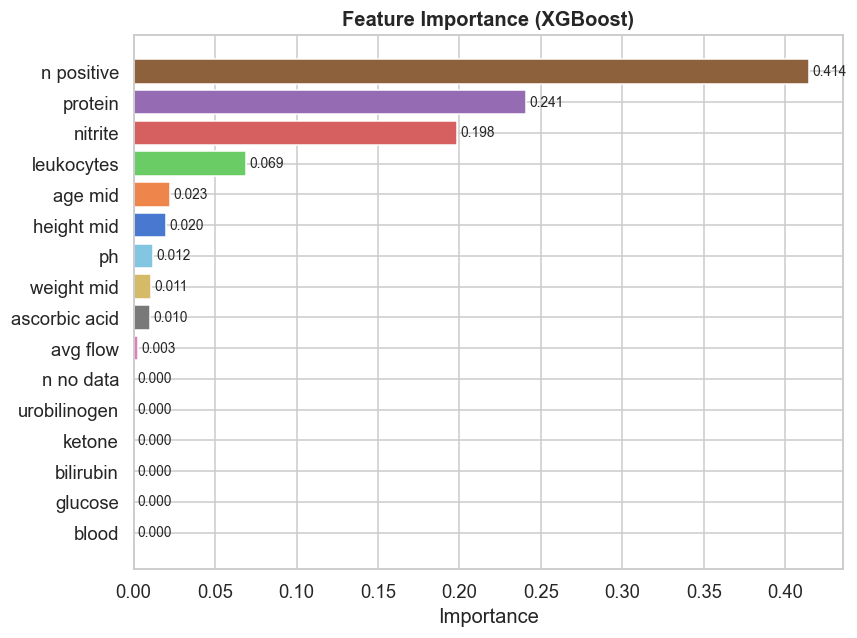

In [9]:
success = learner.train(verbose=True)

if success:
    fi = learner.model.feature_importances_
    fig, ax = plt.subplots(figsize=(8, 6))
    order = np.argsort(fi)
    bars = ax.barh([FEATURES[i].replace('_', ' ') for i in order], fi[order],
                   color=sns.color_palette('muted', len(FEATURES)))
    ax.set_xlabel('Importance')
    ax.set_title('Feature Importance (XGBoost)', fontweight='bold')
    for bar, val in zip(bars, fi[order]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()


## Auto-Labeling

Labels all measurements whose model confidence is at least `UNCERTAINTY_THRESHOLD`, plus any case caught by a clinical safety rule.


In [10]:
if learner.trained:
    n_auto = learner.auto_label()
    s = learner.stats()
    rule_info = f" | {s['rule']} via clinical rule" if s.get('rule', 0) else ""
    print(f'{n_auto} measurements automatically labeled '
          f'(Model conf ≥ {UNCERTAINTY_THRESHOLD:.0%} or clinical rule)')
    print(f'Status: {s["labeled"]}/{s["total"]} labeled | {s["unlabeled"]} left{rule_info}')
else:
    print('Please execute "Training" first.')


  → 62 cases labeled via clinical safety rule
295 measurements automatically labeled (Model conf ≥ 75% or clinical rule)
Status: 345/872 labeled | 527 left | 62 via clinical rule


## Human-in-the-Loop


In [16]:
class ReviewUI:
    """UI for reviewing the most uncertain unlabeled cases."""

    def __init__(self, learner, label_options, n=5):
        self.learner = learner
        self.labels  = label_options
        self.n       = n
        self.queue   = pd.DataFrame()
        self.idx     = 0
        self.out     = widgets.Output()
        self._refresh_queue()
        self._build_ui()

    def _refresh_queue(self):
        self.queue = self.learner.get_uncertain_cases(self.n)
        self.idx = 0

    def _current(self):
        if self.idx >= len(self.queue):
            return None
        return self.queue.iloc[self.idx]

    def _build_ui(self):
        self.title = widgets.HTML()
        self.biomarker_html = widgets.HTML()
        self.info_box = widgets.HTML()

        btn_colors = ['#4C9F6F', '#E8A838', '#D95F3B', '#8A8A8A']
        self.label_buttons = []
        for lbl, col in zip(self.labels, btn_colors[:len(self.labels)]):
            b = widgets.Button(description=lbl,
                               layout=widgets.Layout(width='150px', height='38px'),
                               style={'button_color': col})
            b.on_click(lambda ev, l=lbl: self._on_label(l))
            self.label_buttons.append(b)

        self.confirm_btn = widgets.Button(
            description='Confirm prediction',
            layout=widgets.Layout(width='200px', height='38px'),
            style={'button_color': '#2E7D9E'})
        self.confirm_btn.on_click(lambda _: self._confirm_predicted())

        self.skip_btn = widgets.Button(description='Skip',
                                       layout=widgets.Layout(width='150px'))
        self.skip_btn.on_click(lambda _: self._advance())

        self.refresh_btn = widgets.Button(description='Refresh',
                                          layout=widgets.Layout(width='150px'))
        self.refresh_btn.on_click(lambda _: self._refresh_and_render())

        self.ui = widgets.VBox([
            self.title,
            self.biomarker_html,
            self.info_box,
            widgets.HTML('<hr style="margin:8px 0">'),
            widgets.HTML('<b>Korrektes Label:</b>'),
            widgets.HBox(self.label_buttons,
                         layout=widgets.Layout(flex_flow='row wrap', gap='6px')),
            widgets.HBox([self.confirm_btn, self.skip_btn, self.refresh_btn],
                         layout=widgets.Layout(gap='8px', margin='8px 0')),
            self.out,
        ], layout=widgets.Layout(padding='16px', border='1px solid #ddd',
                                  border_radius='8px', max_width='900px'))
        self._render()
        display(self.ui)

    def _render(self):
        row = self._current()
        s = self.learner.stats()
        pct = int(s['labeled'] / s['total'] * 100) if s['total'] else 0

        if row is None:
            self.title.value = (
                f'<p style="color:#4C9F6F;font-size:1.1em">All uncertain cases labeled! '
                f'({s["unlabeled"]} unlabeled left)</p>'
            )
            self.biomarker_html.value = ''
            self.info_box.value = ''
            return

        self.title.value = f"""
        <div style="font-family:sans-serif">
          <b style="font-size:1.1em">Unsicherer Fall – ID {int(row.id)}</b>
          <span style="color:#888;margin-left:10px">{self.idx+1}/{len(self.queue)} in Queue</span>
          <div style="background:#eee;border-radius:4px;height:8px;margin:6px 0;width:400px">
            <div style="background:#4C9F6F;width:{pct}%;height:100%;border-radius:4px"></div>
          </div>
          <span style="color:#555;font-size:0.88em">
            👤 {s['human']} | 🤖 {s['model_auto']} | ❓ {s['unlabeled']}
          </span>
        </div>"""

        self.biomarker_html.value = _biomarker_panel_html(row)

        conf_color = '#D95F3B' if row.confidence < 0.6 else '#E8A838'
        feature_rows = ''.join([
            f"<tr><td style='padding:2px 8px 2px 0;font-weight:500'>{f}</td>"
            f"<td style='padding:2px 4px'>{_fmt_feat(row[f], FEATURE_UNITS[f])}</td>"
            f"<td><div style='background:#eee;border-radius:3px;height:10px;width:120px'>"
            f"<div style='background:#5B8FC9;width:{_bar_width_pct(row[f], FEATURE_REFS[f]):.0f}%;"
            f"height:100%;border-radius:3px'></div></div></td></tr>"
            for f in NUMERIC_FEATURES + DERIVED_FEATURES + DEMO_FEATURES
        ])
        self.info_box.value = f"""
        <div style="font-family:sans-serif;margin-top:10px">
          <div style="background:#fff3e0;border:1px solid #FFB74D;border-radius:6px;
                      padding:10px;margin-bottom:12px;max-width:520px">
            <b>Model prediction:</b>
            <span style="font-size:1.1em;margin:0 8px">{row.predicted}</span>
            <span style="background:{conf_color};color:white;padding:2px 8px;
                         border-radius:10px;font-size:0.85em">
              {row.confidence:.1%} Confidence
            </span><br>
            <span style="color:#888;font-size:0.85em">Uncertainty: {row.uncertainty:.2%}</span>
          </div>
          <table style="border-collapse:collapse;font-size:0.9em">{feature_rows}</table>
        </div>"""

    def _on_label(self, label):
        row = self._current()
        if row is None or not label:
            return
        self.learner.apply_label(int(row.id), label)
        with self.out:
            clear_output(wait=True)
            print(f'ID {int(row.id)} → "{label}" (human)')
        self._advance()

    def _confirm_predicted(self):
        row = self._current()
        if row is None:
            return
        self._on_label(row.predicted)

    def _advance(self):
        self.idx += 1
        self._render()

    def _refresh_and_render(self):
        with self.out:
            clear_output(wait=True)
            print('Refresh uncertain cases...')
        self._refresh_queue()
        self._render()


if learner.trained:
    review_ui = ReviewUI(learner, LABEL_OPTIONS, n=5)
else:
    print('Please execute Labeling and Training first!')


## Iterative Active Learning Loop


In [12]:
MAX_ITERATIONS = 10
out_loop = widgets.Output()


def run_iteration(_b):
    with out_loop:
        clear_output(wait=True)
        s = learner.stats()
        print(f'─── Iteration | Labeled: {s["labeled"]} | Unlabeled: {s["unlabeled"]} ───')
        if not learner.train(verbose=True):
            return
        n = learner.auto_label()
        s2 = learner.stats()
        print(f'Auto-labeled: {n} | Still unlabeled: {s2["unlabeled"]}')
        unc = learner.get_uncertain_cases(5)
        if len(unc):
            print(f'\n {len(unc)} uncertain cases – Please run the human-in-the-loop cell again.')
        else:
            print('No uncertain cases – start the next iteration.')


iter_btn = widgets.Button(description='Next iteration', button_style='primary',
                          layout=widgets.Layout(width='200px', height='40px'))
iter_btn.on_click(run_iteration)

display(widgets.VBox([
    widgets.HTML('<b>Active Learning Loop:</b> trains → auto-labels → shows uncertain cases'),
    iter_btn,
    out_loop,
]))


## Confidence plateau

If model confidence plateaus and many cases stay unlabeled, run the two cells below. The first retrains and shows the confidence distribution of the remaining cases; the second uses a phased strategy that labels remaining cases at relaxed thresholds.


In [ ]:
learner.train(verbose=True)

ids, X = learner.load_unlabeled()
if ids:
    proba = learner.model.predict_proba(X)
    pred  = learner.le.inverse_transform(proba.argmax(axis=1))
    conf  = proba.max(axis=1)

    print(f'Confidence distribution of the remaining {len(ids)} measurements:')
    print(pd.Series(conf).describe().round(3))

    df_stuck = pd.DataFrame(X, columns=FEATURES)
    df_stuck['id'] = ids
    df_stuck['predicted'] = pred
    df_stuck['confidence'] = conf
    df_stuck = df_stuck.sort_values('confidence', ascending=False)
    print(df_stuck[['id', 'predicted', 'confidence']].head(20).to_string())


In [ ]:
ids, X = learner.load_unlabeled()
if ids:
    proba = learner.model.predict_proba(X)
    pred  = learner.le.inverse_transform(proba.argmax(axis=1))
    conf  = proba.max(axis=1)

    auto_count = 0
    review_count = 0
    certainty  = 0.65
    uncertainty = 0.55

    for mid, p, c in zip(ids, pred, conf):
        if c >= certainty:
            conn.execute("""UPDATE measurements SET label=?, label_source='model',
                         confidence=?, reviewed_at=? WHERE id=?""",
                         (p, float(c), datetime.now().isoformat(), int(mid)))
            auto_count += 1
        elif c >= uncertainty:
            conn.execute("""UPDATE measurements SET label=?, label_source='model_low_conf',
                         confidence=?, reviewed_at=? WHERE id=?""",
                         (p, float(c), datetime.now().isoformat(), int(mid)))
            review_count += 1
        else:
            conn.execute("""UPDATE measurements SET label='uncertain', label_source='human',
                         confidence=?, reviewed_at=? WHERE id=?""",
                         (float(c), datetime.now().isoformat(), int(mid)))

    conn.commit()
    print(f"Auto-label (≥{certainty}): {auto_count}")
    print(f"Low confidence ({uncertainty}–{certainty}): {review_count}")
    print(f"Uncertain (<{uncertainty}): {len(ids) - auto_count - review_count}")
    print(f"Remaining unlabeled: {learner.stats()['unlabeled']}")
else:
    print('No unlabeled cases left.')


## Results


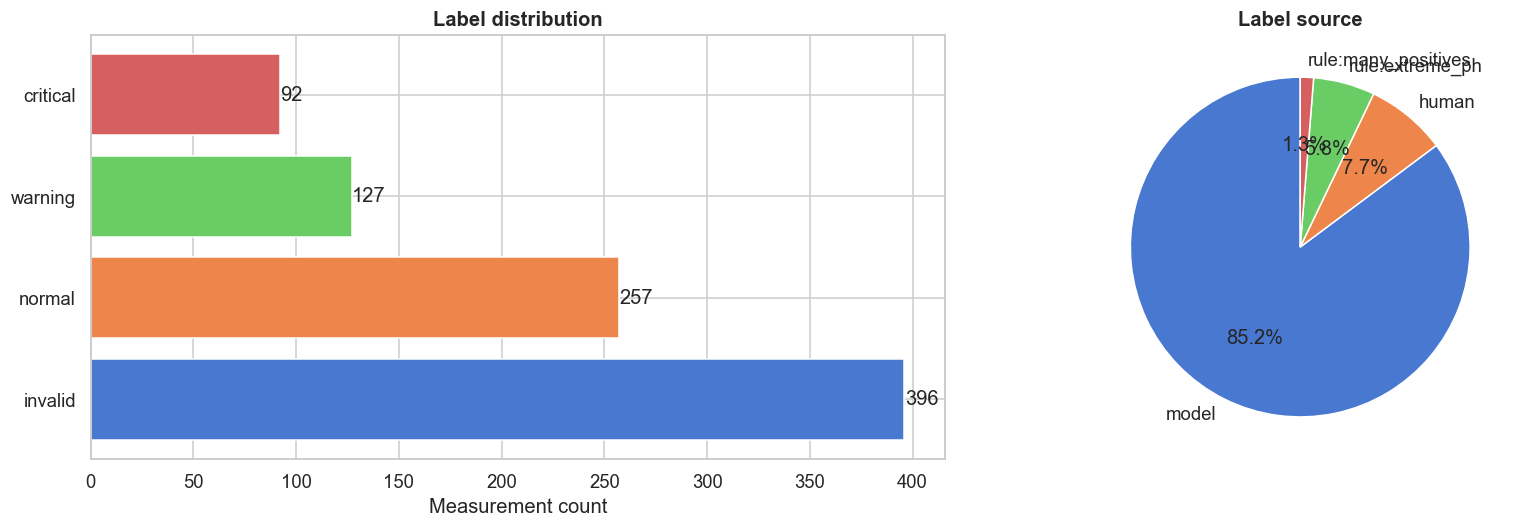

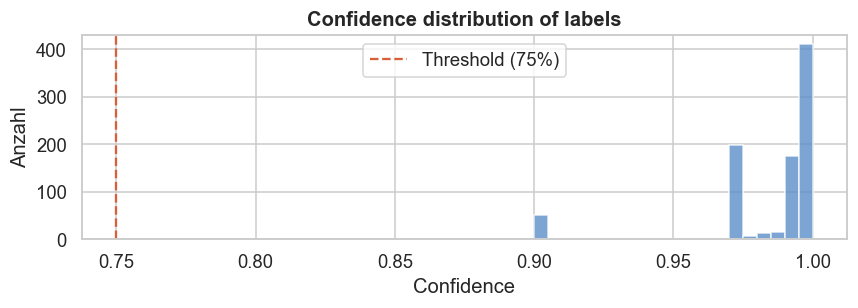

In [17]:
df_labeled = pd.read_sql(
    "SELECT * FROM measurements WHERE label IS NOT NULL", conn)

if len(df_labeled) == 0:
    print('No labeled data.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    vc = df_labeled['label'].value_counts()
    bars = ax.barh(vc.index, vc.values, color=sns.color_palette('muted', len(vc)))
    ax.set_title('Label distribution', fontweight='bold')
    ax.set_xlabel('Measurement count')
    for bar, v in zip(bars, vc.values):
        ax.text(v + 0.3, bar.get_y() + bar.get_height() / 2, str(v), va='center')

    ax = axes[1]
    sc = df_labeled['label_source'].value_counts()
    ax.pie(sc.values, labels=sc.index, autopct='%1.1f%%',
           colors=sns.color_palette('muted', len(sc)), startangle=90)
    ax.set_title('Label source', fontweight='bold')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(df_labeled['confidence'].dropna(), bins=20, color='#5B8FC9',
            alpha=0.8, edgecolor='white')
    ax.axvline(UNCERTAINTY_THRESHOLD, color='#D95F3B', ls='--', lw=1.5,
               label=f'Threshold ({UNCERTAINTY_THRESHOLD:.0%})')
    ax.set_title('Confidence distribution of labels', fontweight='bold')
    ax.set_xlabel('Confidence'); ax.set_ylabel('Anzahl')
    ax.legend()
    plt.tight_layout()
    plt.show()


Classification report on labeled data
              precision    recall  f1-score   support

    critical       1.00      1.00      1.00        92
     invalid       1.00      1.00      1.00       396
      normal       1.00      0.99      1.00       257
     warning       0.98      1.00      0.99       127

    accuracy                           1.00       872
   macro avg       1.00      1.00      1.00       872
weighted avg       1.00      1.00      1.00       872



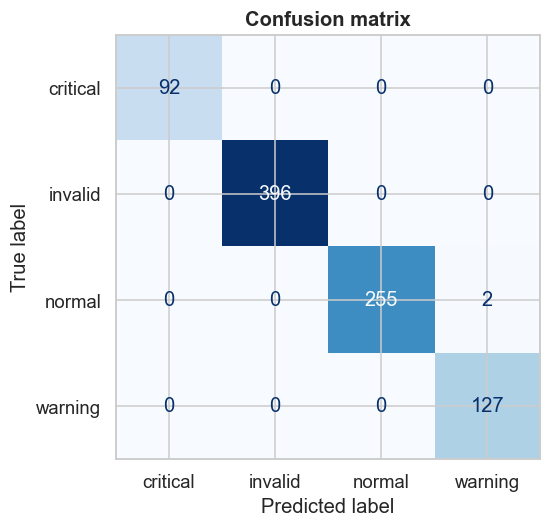

In [18]:
if learner.trained and len(df_labeled) > 0:
    df_lbl_feat = build_feature_frame(conn)
    df_lbl_feat = df_lbl_feat[df_lbl_feat['label'].notna()]
    X_lbl = df_lbl_feat[FEATURES].to_numpy(dtype=float)
    y_lbl = df_lbl_feat['label'].to_numpy()
    y_pred = learner.le.inverse_transform(learner.model.predict(X_lbl))
    print('Classification report on labeled data')
    print(classification_report(y_lbl, y_pred))

    cm = confusion_matrix(y_lbl, y_pred, labels=learner.le.classes_)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=learner.le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title('Confusion matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()


## Export


In [19]:
export_path = f'data/out/labeled_biomarkers_{DB_NAME}.csv'
df_export = pd.read_sql('SELECT * FROM measurements WHERE label IS NOT NULL', conn)
df_export.to_csv(export_path, index=False)
print(f'{len(df_export)} labeled measurements exported → {export_path}')
df_export.head()


872 labeled measurements exported → data/out/labeled_biomarkers_biomarkers.db.csv


,id,measurement_id,patient_id,leukocytes,nitrite,protein,blood,glucose,ascorbic_acid,bilirubin,ketone,urobilinogen,ph,avg_flow,label,label_source,confidence,reviewed_at
0,1,MEASUREMENT_ID-AF3256C7,PATIENT_ID-92922A02,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,5.0,10.76,normal,model,0.994500,2026-05-14T15:37:40.739516
1,2,MEASUREMENT_ID-6A0502BA,PATIENT_ID-92922A02,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,5.0,16.53,normal,model,0.996752,2026-05-14T15:38:10.973829
2,3,MEASUREMENT_ID-3FDB42B9,PATIENT_ID-8450049F,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,5.0,12.82,normal,model,0.995688,2026-05-14T15:37:40.739747
3,4,MEASUREMENT_ID-8DA4A95A,PATIENT_ID-8450049F,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,5.0,4.52,normal,model,0.997340,2026-05-14T15:37:40.739757
4,5,MEASUREMENT_ID-CDB5A710,PATIENT_ID-697FFD0E,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,NEGATIVE,5.0,10.72,normal,model,0.995387,2026-05-14T15:37:22.196391
